In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
uber= '/content/drive/MyDrive/DataSet for practice/UberDataset.csv'
df = pd.read_csv(uber)
df.head(3)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies


In [3]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors= 'coerce')

In [4]:
df['PURPOSE']= df['PURPOSE'].replace(np.nan, 'N.A.').ffill()

In [5]:
df['DATE'] = pd.DatetimeIndex(df['START_DATE']).date
df['TIME'] = pd.DatetimeIndex(df['START_DATE']).hour
df['DAY-NIGHT'] = pd.cut(x=df['TIME'], bins= [0,10,16,21,24], labels= ['MORNING', 'AFTERNOON', 'EVENING', 'NIGHT'])

In [6]:
df.head(4)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY-NIGHT
0,2016-01-01 21:11:00,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,EVENING
1,2016-01-02 01:25:00,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,N.A.,2016-01-02,1.0,MORNING
2,2016-01-02 20:25:00,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,EVENING
3,2016-01-05 17:31:00,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,EVENING


In [7]:
df['CATEGORY'] = df['CATEGORY'].replace(np.nan, 'Personal').ffill()

In [8]:
df.dropna(inplace=True)

In [10]:
df['MONTH'] = pd.DatetimeIndex(df['START_DATE']).month

label_month = { 1.0 : 'JAN', 2.0 : 'FEB', 3.0 : 'MAR', 4.0 : 'APR', 5.0 : 'MAY',
               6.0:'JUNE', 7.0:'JULY', 8.0: 'AUG', 9.0: 'SEPT', 10.0:'OCT',11.0:'NOV', 12.0: 'DEC'}
df['MONTH'] = df.MONTH.map(label_month)
MON = df.MONTH.value_counts(sort=False)


In [11]:
df['DAY'] =df.START_DATE.dt.weekday
label_day = { 0 : 'MON', 1 : 'TUE', 2 : 'WED', 3 : 'THUR', 4 : 'FRI',
               5:'SAT', 6:'SUN'}
df['DAY'] = df.DAY.map(label_day)


###DATA VISULISATIONS.

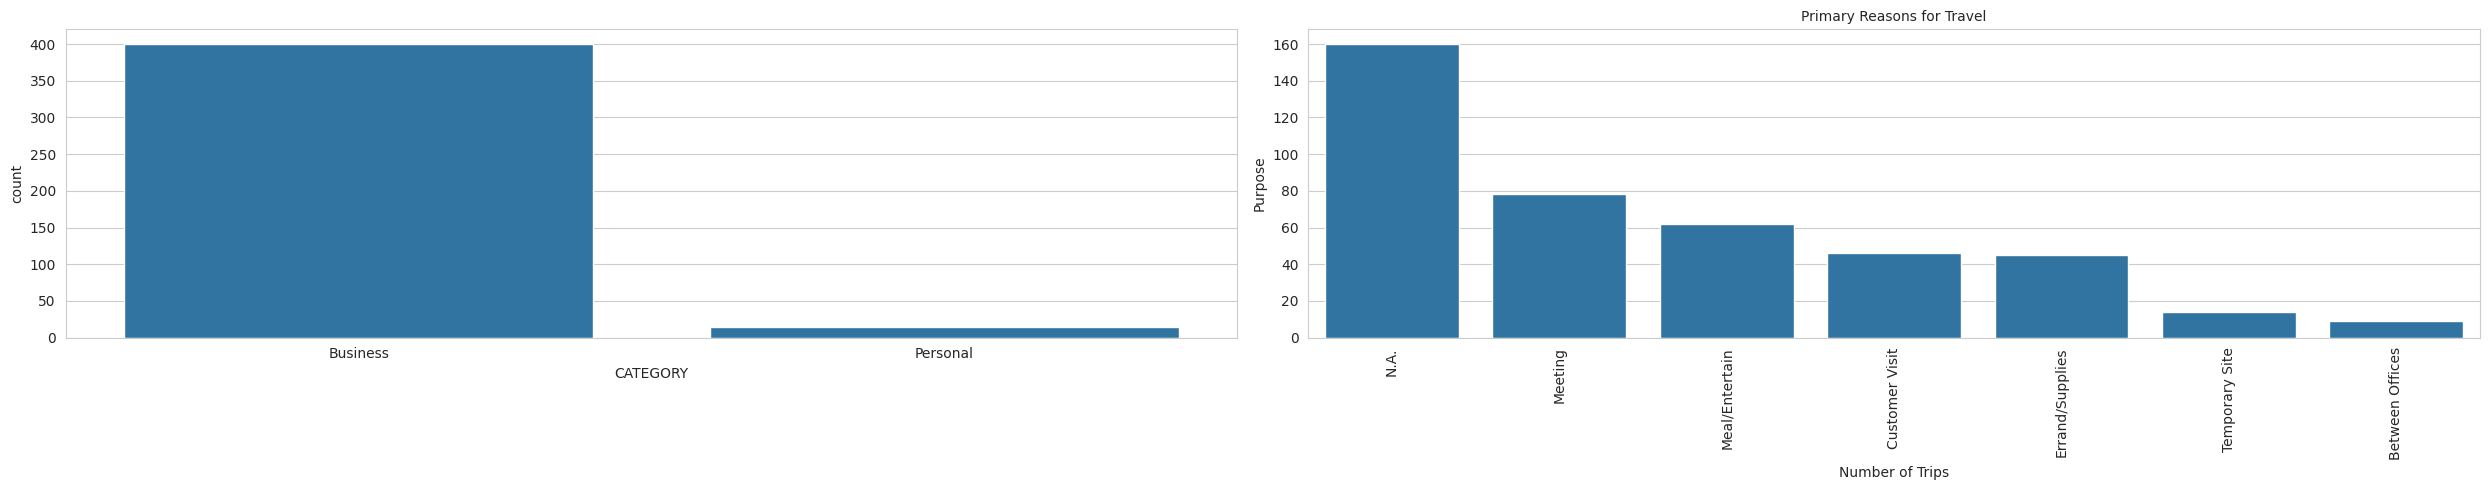

In [29]:
#Distribution of Trip Categories (Business vs Personal)
sns.set_style('whitegrid')
plt.figure(figsize=(25,5))
plt.subplot(1,2,1)
sns.countplot(x=df['CATEGORY'])

##Trip Purpose Analysis (Horizontal for better readability)
plt.subplot(1,2,2)
order = df['PURPOSE'].value_counts().index
sns.countplot(x=df['PURPOSE'], data=df, order=order)
plt.xticks(rotation=90)
plt.title('Primary Reasons for Travel', fontsize=10)
plt.xlabel('Number of Trips')
plt.ylabel('Purpose')
plt.tight_layout()
plt.show()

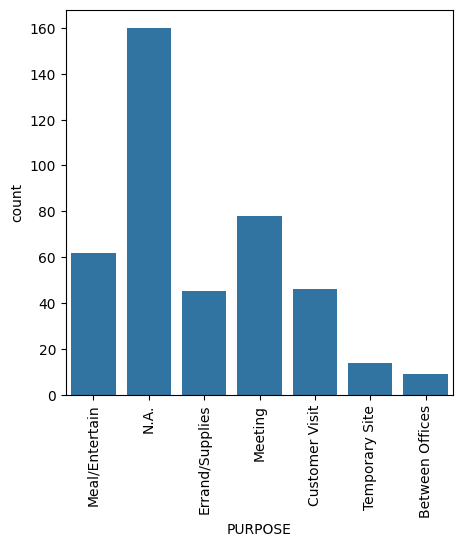

In [19]:
#For which purpose people most book the rides for.
plt.figure(figsize=(5,5))
sns.countplot(x=df['PURPOSE'], data=df)
plt.xticks(rotation=90)
plt.show()

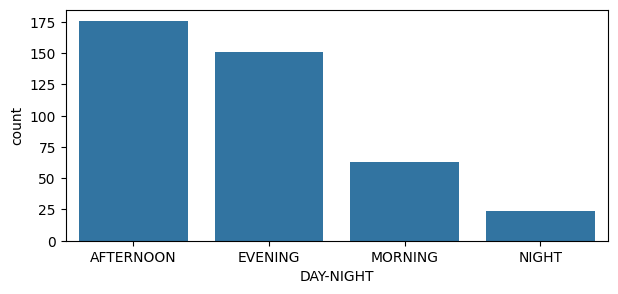

In [16]:
#code to findout at what time people book the uber most.
plt.figure(figsize=(7,3))
orde = df['DAY-NIGHT'].value_counts().index
sns.countplot(x=df['DAY-NIGHT'],data=df,order=orde)
plt.show()

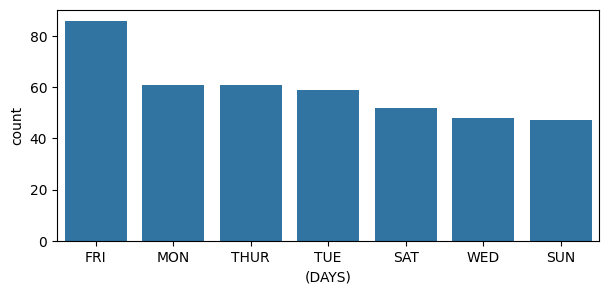

In [17]:
#On which days of the week people book uber rides the most.
plt.figure(figsize=(7,3))
ors= df['DAY'].value_counts().index
label_day= df.DAY.value_counts()
sns.barplot(x=label_day.index , y= label_day, order=ors )
plt.xlabel('(DAYS)')
plt.show()